In [1]:
import sqlite3
import numpy as np
import io
from PIL import Image
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.metrics import Precision, Recall
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# establish global variables
DB_PATH = "faces.db"
CLASSES = ['YOUNG', 'MIDDLE', 'OLD']

In [3]:
def load_images_from_db(db_path):
    """
    Load all training images and labels from the database.
    Returns: X (images), y (integer labels), filenames
    """
    print("[INFO] Connecting to database...")
    conn = sqlite3.connect(db_path)
    cur = conn.cursor()
    
    # fetch all training images
    cur.execute("""
        SELECT id, filename, class, image 
        FROM images 
        WHERE is_training = 1
        ORDER BY id
    """)
    
    rows = cur.fetchall()
    conn.close()
    
    print(f"[INFO] Found {len(rows)} training images in database")
    
    images = []
    labels = []
    filenames = []
    
    print("[INFO] Loading and preprocessing images...")
    for idx, (img_id, filename, class_label, img_blob) in enumerate(rows):
        try:
            # convert BLOB to image using PIL and then cv2 format
            img = Image.open(io.BytesIO(img_blob)).convert("RGB")
            
            img = img.resize((128, 128))
            
            # Convert to numpy array and normalize
            img_array = np.array(img) / 255.0
            
            images.append(img_array)
            labels.append(class_label)
            filenames.append(filename)
            
            # Progress indicator
            if (idx + 1) % 100 == 0:
                print(f"  Processed {idx + 1}/{len(rows)} images...")
                
        except Exception as e:
            print(f"[WARNING] Failed to process image {filename}: {e}")
            continue
    
    print(f"[SUCCESS] Loaded {len(images)} images")
    
    return np.array(images), np.array(labels), filenames

# load data from database
train_images, y_labels, filenames = load_images_from_db(DB_PATH)

[INFO] Connecting to database...
[INFO] Found 19906 training images in database
[INFO] Loading and preprocessing images...
  Processed 100/19906 images...
  Processed 200/19906 images...
  Processed 300/19906 images...
  Processed 400/19906 images...
  Processed 500/19906 images...
  Processed 600/19906 images...
  Processed 700/19906 images...
  Processed 800/19906 images...
  Processed 900/19906 images...
  Processed 1000/19906 images...
  Processed 1100/19906 images...
  Processed 1200/19906 images...
  Processed 1300/19906 images...
  Processed 1400/19906 images...
  Processed 1500/19906 images...
  Processed 1600/19906 images...
  Processed 1700/19906 images...
  Processed 1800/19906 images...
  Processed 1900/19906 images...
  Processed 2000/19906 images...
  Processed 2100/19906 images...
  Processed 2200/19906 images...
  Processed 2300/19906 images...
  Processed 2400/19906 images...
  Processed 2500/19906 images...
  Processed 2600/19906 images...
  Processed 2700/19906 image

In [4]:
# Create numerical mapping
class_mapping = {'YOUNG': 0, 'MIDDLE': 1, 'OLD': 2}
train_labels = np.array([class_mapping[label] for label in y_labels])

# Convert to categorical (one-hot encoding)
train_labels = tf.keras.utils.to_categorical(train_labels, num_classes=3)

print("\n[INFO] Label encoding:")
for label, idx in class_mapping.items():
    count = np.sum(np.argmax(train_labels, axis=1) == idx)
    print(f"  {label}: {idx} ({count} images)")


[INFO] Label encoding:
  YOUNG: 0 (6706 images)
  MIDDLE: 1 (10804 images)
  OLD: 2 (2396 images)


In [5]:
# establish an image preprocessing process
def load_and_preprocess_image(image_path, target_size=(128, 128)):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, target_size)
    image = image / 255.0
    return image

In [6]:
X = train_images.astype('float32')
y_int = np.argmax(train_labels, axis=1)

X_train, X_test, y_train_int, y_test_int = train_test_split(
    X, y_int,
    test_size=0.2,
    random_state=42,
    stratify=y_int
)

# Re-encode labels for training the neural network
y_train = tf.keras.utils.to_categorical(y_train_int, num_classes=3)
y_test  = tf.keras.utils.to_categorical(y_test_int,  num_classes=3)

print(f"\n[INFO] Train set shapes: {X_train.shape} {y_train.shape}")
print(f"[INFO] Test set shapes: {X_test.shape} {y_test.shape}")


[INFO] Train set shapes: (15924, 128, 128, 3) (15924, 3)
[INFO] Test set shapes: (3982, 128, 128, 3) (3982, 3)


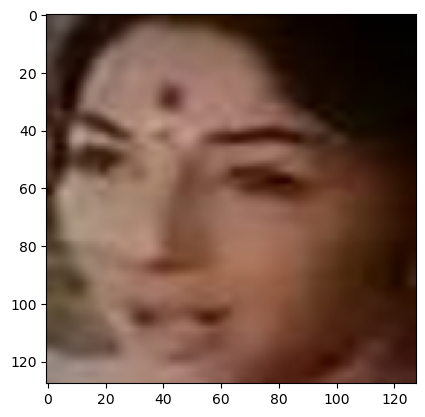

In [7]:
# show an example
plt.imshow(train_images[10])

In [8]:
# check the shape of your images
train_images.shape

(19906, 128, 128, 3)

In [9]:
# check the shape of your labels and ensure the data looks correct (should be all 0-2)
train_labels

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       ...,
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]], shape=(19906, 3))

In [ ]:
# build the model
model = keras.Sequential(
    [
        keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(128, 128, 3)),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(128, (3, 3), activation='relu'),
        keras.layers.MaxPooling2D(),
        keras.layers.Flatten(),
        keras.layers.Dense(3, activation='softmax'),
    ]
)

# compile the model – track accuracy, precision, and recall
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
    ],
)

# train the model
history = model.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=20,
    validation_data=(X_test, y_test),
    shuffle=True,
)

c:\Users\budde\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 150s 588ms/step - accuracy: 0.5803 - loss: 0.8998 - precision: 0.6043 - recall: 0.4256 - val_accuracy: 0.6565 - val_loss: 0.7767 - val_precision: 0.7005 - val_recall: 0.5804
Epoch 2/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 138s 554ms/step - accuracy: 0.6780 - loss: 0.7486 - precision: 0.7122 - recall: 0.6138 - val_accuracy: 0.6828 - val_loss: 0.7273 - val_precision: 0.7129 - val_recall: 0.6311
Epoch 3/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 134s 539ms/step - accuracy: 0.6936 - loss: 0.6921 - precision: 0.7272 - recall: 0.6417 - val_accuracy: 0.6781 - val_loss: 0.7392 - val_precision: 0.7130 - val_recall: 0.6040
Epoch 4/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 136s 546ms/step - accuracy: 0.7298 - loss: 0.6424 - precision: 0.7589 - recall: 0.6854 - val_accuracy: 0.7012 - val_loss: 0.6908 - val_precision: 0.7187 - val_recall: 0.6710
Epoch 5/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 133s 535ms/step - accuracy: 0.7509 - loss: 0.6047 - precision: 0.7761 - recall: 0.7145 - val_accuracy: 0

In [4]:
# evaluate the model on the held-out test set

# true integer labels
y_true = y_test_int

# model predictions
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print("=== Classification report (per-class precision/recall/F1) ===")
print(classification_report(y_true, y_pred, target_names=CLASSES))

# macro-averaged metrics across classes
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro    = recall_score(y_true, y_pred, average='macro')
f1_macro        = f1_score(y_true, y_pred, average='macro')

print(f"\nMacro Precision: {precision_macro:.4f}")
print(f"Macro Recall:    {recall_macro:.4f}")
print(f"Macro F1-score:  {f1_macro:.4f}")

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES,
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()


NameError: name 'y_test_int' is not defined

In [12]:
# save the model for future use
model.save('age_classifier_model.h5')

In [7]:
from workflow_manager import predict, show_stats, query_predictions

In [3]:
# Predict single image
predict("my_face\\myface.jpg")

[INFO] Model loaded from: age_classifier_model.h5
[INFO] Model expects input size: (128, 128)

PREDICTING SINGLE IMAGE

IMAGE: myface.jpg
------------------------------------------------------------
Predicted Age: YOUNG
Confidence: 98.9%

Probability Distribution:
  YOUNG   :  98.9% ███████████████████████████████████████
  MIDDLE  :   0.0% 
  OLD     :   1.1% 



{'success': True,
 'filename': 'myface.jpg',
 'predicted_age': 'YOUNG',
 'confidence': 0.9888305068016052,
 'probabilities': {'YOUNG': np.float32(0.9888305),
  'MIDDLE': np.float32(0.00047204748),
  'OLD': np.float32(0.010697376)},
 'db_id': 19907}

In [8]:
# Predict entire folder
predict("test_cases")

[INFO] Model loaded from: age_classifier_model.h5
[INFO] Model expects input size: (128, 128)

BATCH PREDICTION FROM FOLDER: test_cases

[INFO] Found 4 images

[OK] test_case_1.jpg
     Predicted: YOUNG (confidence: 98.8%)
     Probabilities: YOUNG: 98.8% | MIDDLE: 1.2% | OLD: 0.0%
     Database ID: 19914
------------------------------------------------------------
[OK] test_case_2.JPG
     Predicted: YOUNG (confidence: 98.9%)
     Probabilities: YOUNG: 98.9% | MIDDLE: 0.0% | OLD: 1.1%
     Database ID: 19915
------------------------------------------------------------
[OK] test_case_3.jpg
     Predicted: MIDDLE (confidence: 99.4%)
     Probabilities: YOUNG: 0.6% | MIDDLE: 99.4% | OLD: 0.0%
     Database ID: 19916
------------------------------------------------------------
[OK] test_case_4.JPG
     Predicted: MIDDLE (confidence: 100.0%)
     Probabilities: YOUNG: 0.0% | MIDDLE: 100.0% | OLD: 0.0%
     Database ID: 19917
------------------------------------------------------------

BAT

{'success': True,
 'total': 4,
 'successful': 4,
 'failed': 0,
 'distribution': {'YOUNG': 2, 'MIDDLE': 2, 'OLD': 0},
 'results': [{'filename': 'test_case_1.jpg',
   'predicted_age': 'YOUNG',
   'confidence': 0.987740695476532,
   'db_id': 19914},
  {'filename': 'test_case_2.JPG',
   'predicted_age': 'YOUNG',
   'confidence': 0.9888305068016052,
   'db_id': 19915},
  {'filename': 'test_case_3.jpg',
   'predicted_age': 'MIDDLE',
   'confidence': 0.9941396713256836,
   'db_id': 19916},
  {'filename': 'test_case_4.JPG',
   'predicted_age': 'MIDDLE',
   'confidence': 0.9999988079071045,
   'db_id': 19917}]}

In [5]:
# View database stats
show_stats()


DATABASE STATISTICS
Total images: 19909
  Training images: 19906
  Prediction images: 3

Prediction status:
  Predicted: 3
  Awaiting prediction: 0

Predicted age distribution:
  YOUNG: 3 images



In [6]:
query_predictions(age_category='YOUNG')


PREDICTION RESULTS (3 images)
Filtered by: YOUNG

ID 19907: myface.jpg
  Age: YOUNG | Confidence: 98.9% | Predicted: 2025-11-30 00:39:03.506154
------------------------------------------------------------
ID 19908: myface.JPG
  Age: YOUNG | Confidence: 98.9% | Predicted: 2025-11-30 00:39:03.715582
------------------------------------------------------------
ID 19909: myface1.JPG
  Age: YOUNG | Confidence: 56.9% | Predicted: 2025-11-30 00:39:03.822077
------------------------------------------------------------


[(19907,
  'myface.jpg',
  'YOUNG',
  0.9888305068016052,
  '2025-11-30 00:39:03.506154'),
 (19908,
  'myface.JPG',
  'YOUNG',
  0.9888305068016052,
  '2025-11-30 00:39:03.715582'),
 (19909,
  'myface1.JPG',
  'YOUNG',
  0.5693206191062927,
  '2025-11-30 00:39:03.822077')]

In [7]:
query_predictions(min_confidence=0.8)


PREDICTION RESULTS (2 images)
Minimum confidence: 80.0%

ID 19907: myface.jpg
  Age: YOUNG | Confidence: 98.9% | Predicted: 2025-11-30 00:39:03.506154
------------------------------------------------------------
ID 19908: myface.JPG
  Age: YOUNG | Confidence: 98.9% | Predicted: 2025-11-30 00:39:03.715582
------------------------------------------------------------


[(19907,
  'myface.jpg',
  'YOUNG',
  0.9888305068016052,
  '2025-11-30 00:39:03.506154'),
 (19908,
  'myface.JPG',
  'YOUNG',
  0.9888305068016052,
  '2025-11-30 00:39:03.715582')]